In [1]:
import keras
import tensorflow as tf
from keras import layers as tfkl
import numpy as np
import matplotlib.pyplot as plt
import os

print(tf.__version__)
print(keras.__version__)


2.10.0
2.10.0


# Loading a pre-trained model and MNIST dataset

In [4]:
G = keras.models.load_model('vae_decoder_dim20.keras')
(training_x,training_y) , (test_x , test_y) = tf.keras.datasets.mnist.load_data()

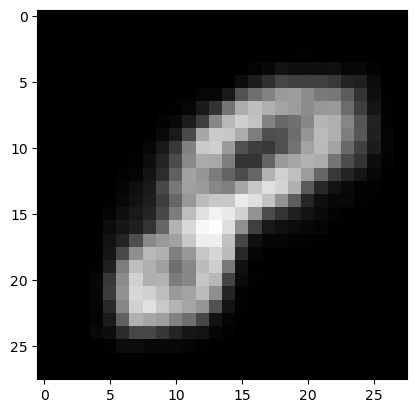

In [17]:
z = np.random.randn(1,20)
image = G(z)
plt.imshow(image[0,:,:,0],cmap='gray')

In [19]:
print(training_x.shape)
training = training_x.reshape((training_x.shape[0] , -1)).astype('float64')
print(training.shape)

(60000, 28, 28)
(60000, 784)


# Building a custom model using the pre-trained DCGAN

The shape of A is: (20, 784)
The shape of x is: (1, 784)
The shape of y is: (1, 20)


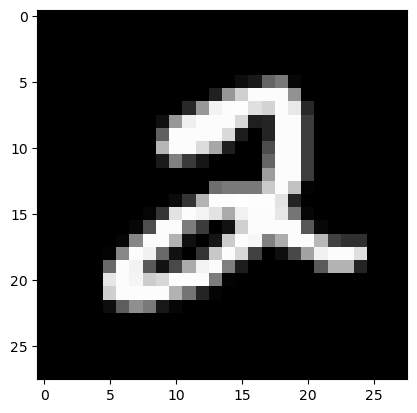

In [23]:
G.trainable = True

for layer in G.layers:
    layer.trainable = False

# Generating the training y

M = 20
N = 784
k = 32
index = 5

A = tf.constant(np.random.randn(M,N)* 1/M , shape=(M,N), dtype = tf.float32)
x_original = tf.constant(training[index,:] , shape = (1,N), dtype = tf.float32)
print(f'The shape of A is: {A.shape}')
print(f'The shape of x is: {x_original.shape}')
plt.imshow(x_original.numpy().reshape(28,28) , cmap='gray')
y = x_original @ tf.transpose(A) + tf.random.normal((1,M)) * 0.01
print(f'The shape of y is: {y.shape}')


In [24]:
# Define the loss function
def loss(z):
    Gz = G(z)
    Gz = Gz[0,:,:,0]
    Gz = tf.reshape(Gz, [1, 784])
    diff = tf.matmul(Gz,A , transpose_b=True) - y
    return tf.norm(diff)

# Optimization step
def train_step(z):
    with tf.GradientTape() as tape:
        current_loss = loss(z)
    gradients = tape.gradient(current_loss, [z])
    optimizer.apply_gradients(zip(gradients, [z]))
    return current_loss

# Training loop
num_epochs = 500
tries = 3
results = []
for i in range(tries):
    z = tf.Variable(np.random.rand(1,20), dtype = tf.float32)
    optimizer = tf.optimizers.Adam(learning_rate=0.01)
    for epoch in range(num_epochs):
        current_loss = train_step(z)
        if epoch % 100 == 0:
            print(f'Epoch {epoch}, Loss: {current_loss.numpy()}')

    print(f'Optimized z has loss : {loss(z).numpy()}')
    results.append((loss(z).numpy() , G(z).numpy()))


Epoch 0, Loss: 383.02825927734375
Epoch 100, Loss: 382.4366455078125
Epoch 200, Loss: 382.32012939453125
Epoch 300, Loss: 382.24725341796875
Epoch 400, Loss: 382.2181091308594
Optimized z has loss : 382.20733642578125
Epoch 0, Loss: 382.8096923828125
Epoch 100, Loss: 382.3870544433594
Epoch 200, Loss: 382.3033142089844
Epoch 300, Loss: 382.2768249511719
Epoch 400, Loss: 382.2415771484375
Optimized z has loss : 382.20831298828125
Epoch 0, Loss: 383.0182800292969
Epoch 100, Loss: 382.4531555175781
Epoch 200, Loss: 382.311767578125
Epoch 300, Loss: 382.26617431640625
Epoch 400, Loss: 382.2519226074219
Optimized z has loss : 382.2107238769531


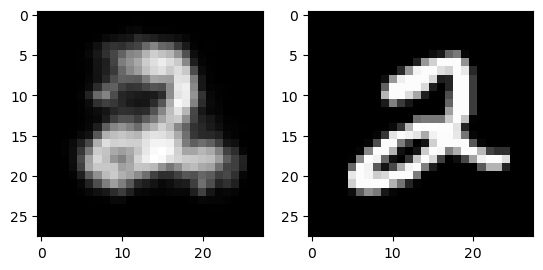

In [25]:
best_idx = np.argmin([r[0] for r in results])
best_x = results[best_idx][1]

fig,axis = plt.subplots(1,2)
axis[0].imshow(best_x[0,:,:,0], cmap='gray')
axis[1].imshow(training_x[index,:,:], cmap='gray')